In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)


In [40]:
df = pd.read_csv('KDD.csv')
df


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,http,SF,325,1159,0,0,0,0,...,1.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,normal,21
1,0,tcp,uucp_path,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.0,0.00,1.0,1.00,neptune,20
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.08,0.07,0.00,0.00,1.0,1.00,0.0,0.00,neptune,21
3,0,tcp,hostnames,S0,0,0,0,0,0,0,...,0.02,0.08,0.00,0.00,1.0,1.00,0.0,0.00,neptune,19
4,0,tcp,hostnames,S0,0,0,0,0,0,0,...,0.08,0.05,0.00,0.00,1.0,1.00,0.0,0.00,neptune,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,icmp,eco_i,SF,8,0,0,0,0,0,...,1.00,0.00,1.00,0.25,0.0,0.00,0.0,0.00,nmap,17
9996,0,tcp,auth,SF,9,38,0,0,0,0,...,0.01,0.05,0.01,0.67,0.0,0.00,0.0,0.00,normal,21
9997,0,tcp,http,SF,255,861,0,0,0,0,...,1.00,0.00,0.00,0.00,0.0,0.00,0.0,0.00,normal,21
9998,0,tcp,http,SF,192,1202,0,0,0,0,...,1.00,0.00,0.10,0.04,0.0,0.01,0.0,0.01,normal,21


In [41]:
df["is_attack"] = (df["label"] != "normal").astype("int8")
df[["label", "is_attack"]].head()


,label,is_attack
0,normal,0
1,neptune,1
2,neptune,1
3,neptune,1
4,neptune,1


In [42]:
df.isna().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
columns_to_remove = ["label", "difficulty", "is_attack", "num_outbound_cmds"]
feature_columns = [c for c in df.columns if c not in columns_to_remove]

X = df[feature_columns].copy()
y = df["is_attack"].copy()

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_columns = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("numeric", StandardScaler(), numeric_columns),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns)
])

X_processed = preprocessor.fit_transform(X)

print("حجم البيانات قبل المعالجة:", X.shape)
print("حجم البيانات بعد المعالجة:", X_processed.shape)


حجم البيانات قبل المعالجة: (10000, 40)
حجم البيانات بعد المعالجة: (10000, 117)


C:\Users\Why\AppData\Local\Temp\ipykernel_7960\1762427223.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [45]:
processed_columns = preprocessor.get_feature_names_out()
X_processed_df = pd.DataFrame(X_processed, columns=processed_columns)
X_processed_df


,numeric__duration,numeric__src_bytes,numeric__dst_bytes,numeric__land,numeric__wrong_fragment,numeric__urgent,numeric__hot,numeric__num_failed_logins,numeric__logged_in,numeric__num_compromised,...,categorical__flag_REJ,categorical__flag_RSTO,categorical__flag_RSTOS0,categorical__flag_RSTR,categorical__flag_S0,categorical__flag_S1,categorical__flag_S2,categorical__flag_S3,categorical__flag_SF,categorical__flag_SH
0,-0.110604,-0.013469,-0.034665,-0.026467,-0.092793,-0.016332,-0.10249,-0.03547,1.258562,-0.023177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.110604,-0.013492,-0.042618,-0.026467,-0.092793,-0.016332,-0.10249,-0.03547,-0.794557,-0.023177,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.110604,-0.013492,-0.042618,-0.026467,-0.092793,-0.016332,-0.10249,-0.03547,-0.794557,-0.023177,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.110604,-0.013492,-0.042618,-0.026467,-0.092793,-0.016332,-0.10249,-0.03547,-0.794557,-0.023177,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-0.110604,-0.013492,-0.042618,-0.026467,-0.092793,-0.016332,-0.10249,-0.03547,-0.794557,-0.023177,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.110604,-0.013491,-0.042618,-0.026467,-0.092793,-0.016332,-0.10249,-0.03547,-0.794557,-0.023177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9996,-0.110604,-0.013491,-0.042357,-0.026467,-0.092793,-0.016332,-0.10249,-0.03547,1.258562,-0.023177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9997,-0.110604,-0.013474,-0.036710,-0.026467,-0.092793,-0.016332,-0.10249,-0.03547,1.258562,-0.023177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9998,-0.110604,-0.013479,-0.034370,-0.026467,-0.092793,-0.016332,-0.10249,-0.03547,1.258562,-0.023177,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [46]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_processed)

print("الحجم قبل PCA:", X_processed.shape)
print("الحجم بعد PCA:", X_pca.shape)
print("نسبة المعلومات المحتفظ بها:", pca.explained_variance_ratio_.sum())


الحجم قبل PCA: (10000, 117)
الحجم بعد PCA: (10000, 23)
نسبة المعلومات المحتفظ بها: 0.9508792003781987


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("حجم بيانات التدريب:", X_train.shape)
print("حجم بيانات الاختبار:", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


حجم بيانات التدريب: (8000, 23)
حجم بيانات الاختبار: (2000, 23)
is_attack
0    4238
1    3762
Name: count, dtype: int64
is_attack
0    1059
1     941
Name: count, dtype: int64


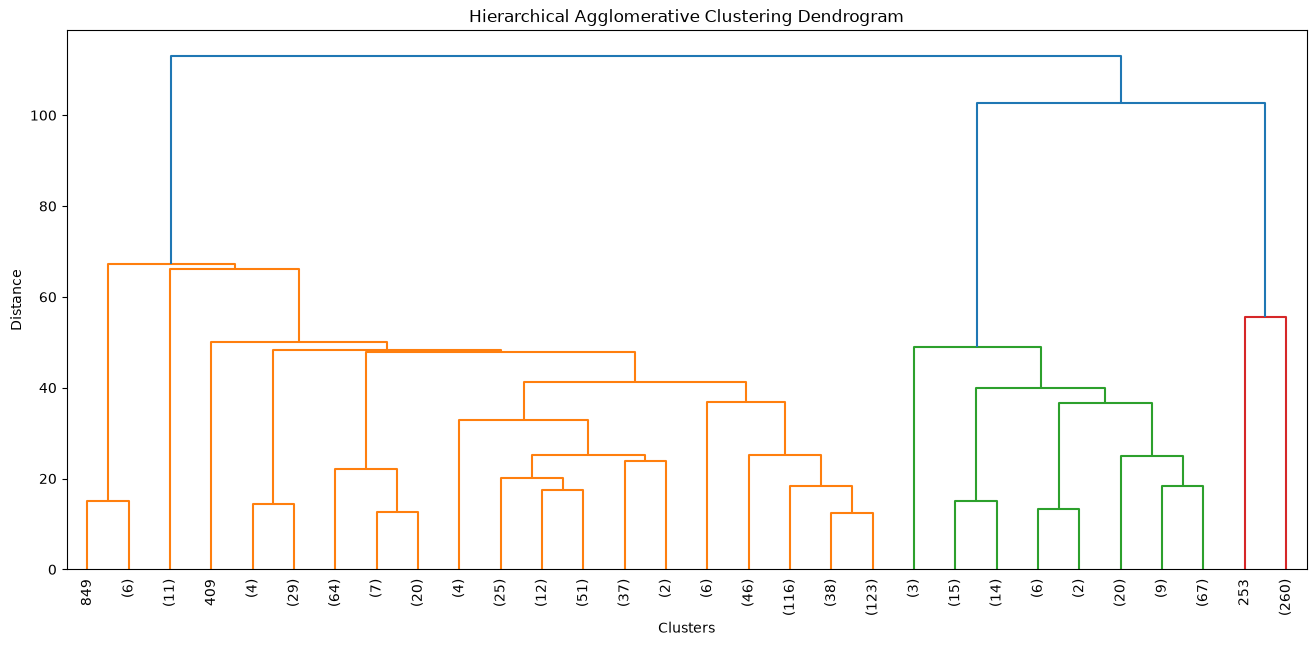

In [48]:
rng = np.random.default_rng(42)
sample_size = min(1000, len(X_train))
sample_idx = rng.choice(len(X_train), size=sample_size, replace=False)

linked = linkage(X_train[sample_idx], method="ward")

plt.figure(figsize=(16, 7))
dendrogram(linked, truncate_mode="lastp", p=30, show_leaf_counts=True, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Agglomerative Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()



In [49]:
n_clusters = 30
hac_model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward", metric="euclidean")
clusters_train = hac_model.fit_predict(X_train)

print("تم التدريب على:", X_train.shape[0], "سجل")
print(pd.Series(clusters_train).value_counts().sort_index())


تم التدريب على: 8000 سجل
0        3
1        2
2       57
3       91
4        3
5       55
6      518
7      190
8      876
9      419
10     262
11       6
12       9
13     242
14     603
15    2129
16      18
17       3
18       1
19      63
20      25
21      86
22     115
23     245
24     167
25       6
26     146
27       5
28    1225
29     430
Name: count, dtype: int64


In [50]:
cluster_ids = np.sort(np.unique(clusters_train))
cluster_centers = np.vstack([
    X_train[clusters_train == cid].mean(axis=0) for cid in cluster_ids
])

test_distances = cdist(X_test, cluster_centers, metric="mahalanobis")
clusters_test = cluster_ids[np.argmin(test_distances, axis=1)]

print("تم الاختبار على:", X_test.shape[0], "سجل")
print(pd.Series(clusters_test).value_counts().sort_index())


تم الاختبار على: 2000 سجل
2       5
3      22
5      14
6     125
7      47
8     258
9      74
10     42
11      2
12      5
13     59
14    133
15    572
16      1
17      4
19     11
20      6
21     26
22     29
23     54
24     60
25      1
26     56
27      1
28    278
29    115
Name: count, dtype: int64


In [51]:
cluster_summary = (
    pd.DataFrame({"cluster": clusters_train, "true_label": df.loc[y_train.index, "label"].to_numpy()})
    .groupby("cluster")["true_label"]
    .agg(lambda s: s.value_counts().idxmax())
)

print("العنصر الأغلب داخل كل مجموعة (للفهم فقط):")
print(cluster_summary)


العنصر الأغلب داخل كل مجموعة (للفهم فقط):
cluster
0        ftp_write
1           normal
2        portsweep
3           normal
4           normal
5          ipsweep
6           normal
7            satan
8           normal
9           normal
10          normal
11            perl
12    guess_passwd
13          normal
14          normal
15         neptune
16          normal
17            land
18          normal
19        teardrop
20          normal
21       portsweep
22           smurf
23         ipsweep
24          normal
25          normal
26          normal
27     warezmaster
28          normal
29         neptune
Name: true_label, dtype: str


In [52]:
silhouette_train = silhouette_score(X_train, clusters_train)
db_train = davies_bouldin_score(X_train, clusters_train)
ch_train = calinski_harabasz_score(X_train, clusters_train)

silhouette_test = silhouette_score(X_test, clusters_test)
db_test = davies_bouldin_score(X_test, clusters_test)
ch_test = calinski_harabasz_score(X_test, clusters_test)

print("=== جودة التجميع على بيانات التدريب ===")
print("Silhouette Score:", silhouette_train)
print("Davies-Bouldin Index:", db_train)
print("Calinski-Harabasz Index:", ch_train)

print("\n=== جودة التجميع على بيانات الاختبار ===")
print("Silhouette Score:", silhouette_test)
print("Davies-Bouldin Index:", db_test)
print("Calinski-Harabasz Index:", ch_test)


=== جودة التجميع على بيانات التدريب ===
Silhouette Score: 0.533281583191254
Davies-Bouldin Index: 0.7242948873211651
Calinski-Harabasz Index: 2494.9738410722657

=== جودة التجميع على بيانات الاختبار ===
Silhouette Score: 0.5508483277628254
Davies-Bouldin Index: 0.744455150908726
Calinski-Harabasz Index: 300.9121513361292
